In [141]:
import pandas as pd
import numpy as np
import sys
import os
notebook_dir = os.getcwd() 
src_path = os.path.abspath(os.path.join(notebook_dir, ".."))
sys.path.append(src_path)
from dota_db import DotaDB
db = DotaDB()

In [142]:
query = 'SELECT * FROM match_details'
matches = db.select_to_df(query, table='match_details')
query = 'SELECT * FROM patches'
patches = db.select_to_df(query, table='patches')

In [143]:
from sklearn.preprocessing import PowerTransformer
df = pd.merge(
    matches, 
    patches, 
    left_on='gameVersionId', 
    right_on='id').rename(columns={'id_y': 'patch_id'})
df = df[['didRadiantWin', 'avg_radiant_rating', 'avg_dire_rating', 'radiant_draft_score', 'dire_draft_score', 'patch_id']]
df = df.dropna(subset=['avg_radiant_rating', 'avg_dire_rating', 'radiant_draft_score', 'dire_draft_score'], axis=0)
pt = PowerTransformer()
df['rating_diff'] = pt.fit_transform(pd.DataFrame(df['avg_radiant_rating'] - df['avg_dire_rating']))
df['draft_diff'] = pt.fit_transform(pd.DataFrame(df['radiant_draft_score'] - df['dire_draft_score']))
df_train = df[df['patch_id'] <= 178]
df_test = df[df['patch_id'] > 178]
len(df_train) / len(matches)

0.8279030624477074

In [144]:
X_train = df_train[['rating_diff', 'draft_diff']].values
X_test = df_test[['rating_diff', 'draft_diff']].values
y_train = df_train['didRadiantWin'].astype('int').values
y_test = df_test['didRadiantWin'].astype('int').values

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
log_reg_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression())
])
log_reg_pipeline.fit(X_train, y_train)

AttributeError: This 'Pipeline' has no attribute 'fit_transform'

Test set accuracy: 0.6048928961121002
              precision    recall  f1-score   support

           0       0.59      0.58      0.58     16635
           1       0.62      0.63      0.63     18191

    accuracy                           0.60     34826
   macro avg       0.60      0.60      0.60     34826
weighted avg       0.60      0.60      0.60     34826



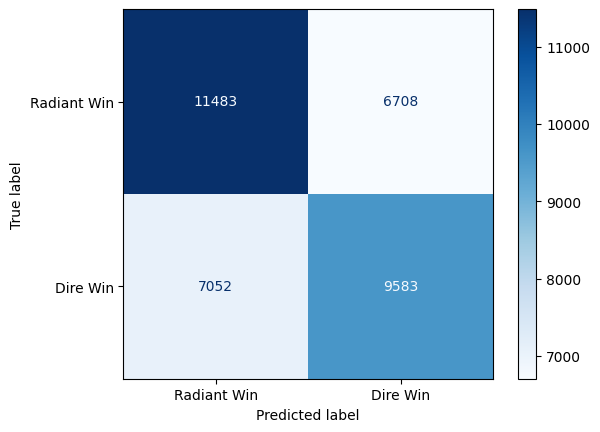

In [146]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
y_pred = log_reg_pipeline.predict(X_test)
print(f'Test set accuracy: {accuracy_score(y_test, y_pred)}')
print(f'{classification_report(y_test, y_pred)}')
cm = confusion_matrix(y_test, y_pred, labels=[1, 0])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Radiant Win', 'Dire Win'])
disp.plot(cmap=plt.cm.Blues)
plt.show()

In [ ]:
log_reg_pipeline.named_steps['model'].coef_

In [147]:
import joblib
joblib.dump(log_reg_pipeline, f'{src_path}/models/log_reg_model.joblib')
print('Model object saved')

Model object saved


In [151]:
from sklearn.ensemble import RandomForestClassifier
rand_forest_pipeline = Pipeline([
    ('model', RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ))
])
rand_forest_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If fl

Test set accuracy: 0.6019640498478148
              precision    recall  f1-score   support

           0       0.58      0.60      0.59     16635
           1       0.62      0.61      0.61     18191

    accuracy                           0.60     34826
   macro avg       0.60      0.60      0.60     34826
weighted avg       0.60      0.60      0.60     34826



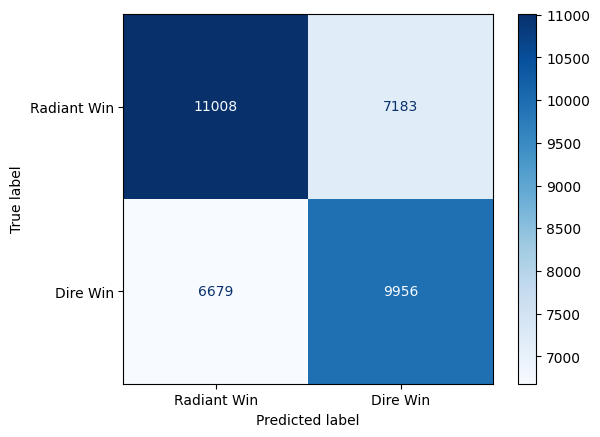

In [152]:
y_pred = rand_forest_pipeline.predict(X_test)
print(f'Test set accuracy: {accuracy_score(y_test, y_pred)}')
print(f'{classification_report(y_test, y_pred)}')
cm = confusion_matrix(y_test, y_pred, labels=[1, 0])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Radiant Win', 'Dire Win'])
disp.plot(cmap=plt.cm.Blues)
plt.show()